In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/movies_clean.csv")
print(df.shape)
df.head()

(1279, 6)


,Film,Year,Awards,Nominations,Decade,Win_Rate
0,One Battle After Another,2025,6,13,2020,0.461538
1,Sinners,2025,4,16,2020,0.250000
2,Frankenstein,2025,3,9,2020,0.333333
3,KPop Demon Hunters,2025,2,2,2020,1.000000
4,Hamnet,2025,1,8,2020,0.125000


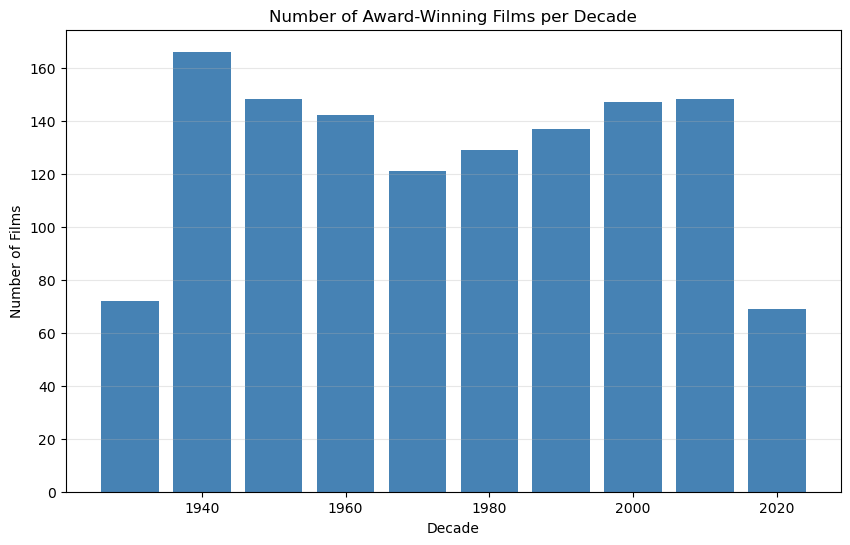

In [5]:
plt.figure(figsize=(10, 6))
decade_counts = df['Decade'].value_counts().sort_index()
plt.bar(decade_counts.index, decade_counts.values, width=8, color='steelblue')
plt.title('Number of Award-Winning Films per Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Films')
plt.grid(axis='y', alpha=0.3)
plt.savefig('movies_per_decade.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Award-winning films peaked in the 1940s (166 films) and dipped 
in the 1930s and 2020s — the 1930s due to fewer total releases industry-wide, 
and the 2020s simply because the decade isn't finished yet.

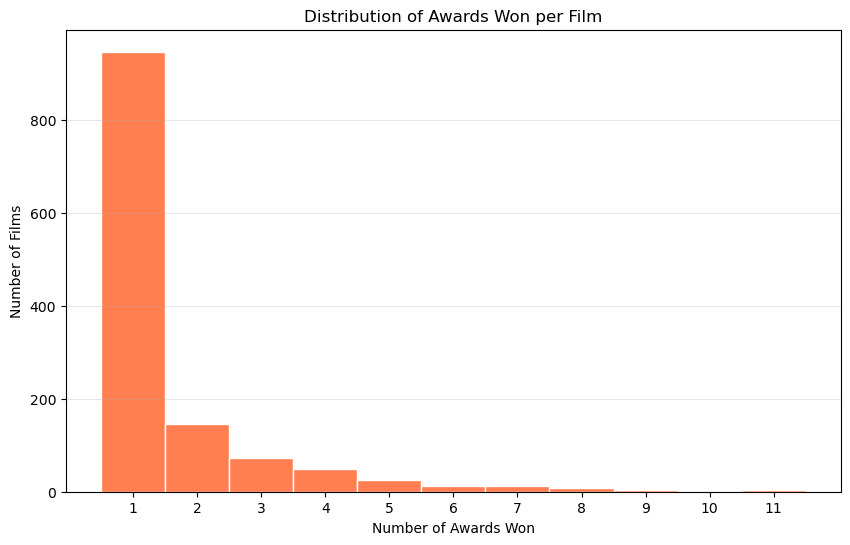

In [6]:
plt.figure(figsize=(10,6))

plt.hist(df['Awards'], bins=range(1,13), color='coral', edgecolor='white', align='left')

plt.title('Distribution of Awards Won per Film')
plt.xlabel('Number of Awards Won')
plt.ylabel('Number of Films')
plt.xticks(range(1, 12))
plt.grid(axis='y', alpha=0.3)
plt.savefig('awards_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Most films win only 1 award, with a sharp drop-off after that — 
winning multiple Oscars is rare, and sweeping 8+ awards is exceptional.

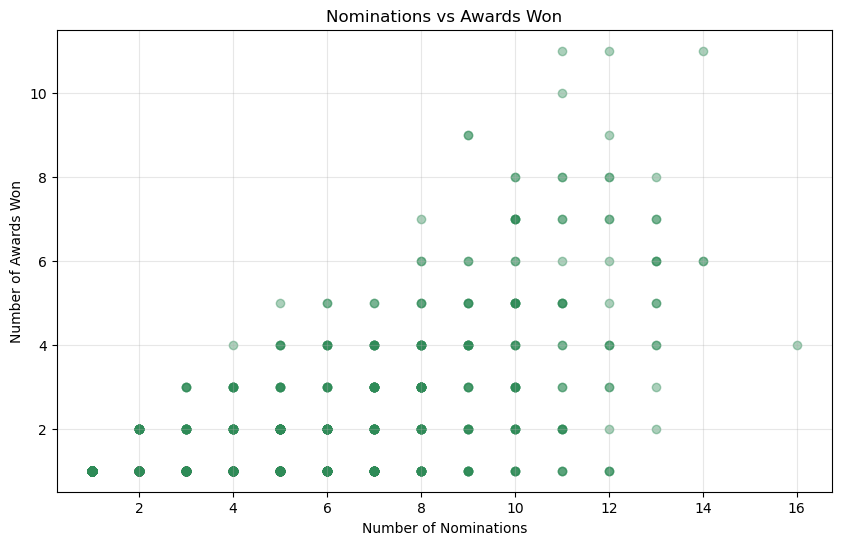

In [7]:
plt.figure(figsize=(10,6))

plt.scatter(df['Nominations'], df['Awards'], alpha=0.4, color='seagreen')

plt.title('Nominations vs Awards Won')
plt.xlabel('Number of Nominations')
plt.ylabel('Number of Awards Won')
plt.grid(alpha=0.3)
plt.savefig('nominations_vs_awards.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** There's a moderate positive relationship (r = 0.69) between 
nominations and wins — more nominations generally means more wins, but 
it's far from guaranteed.

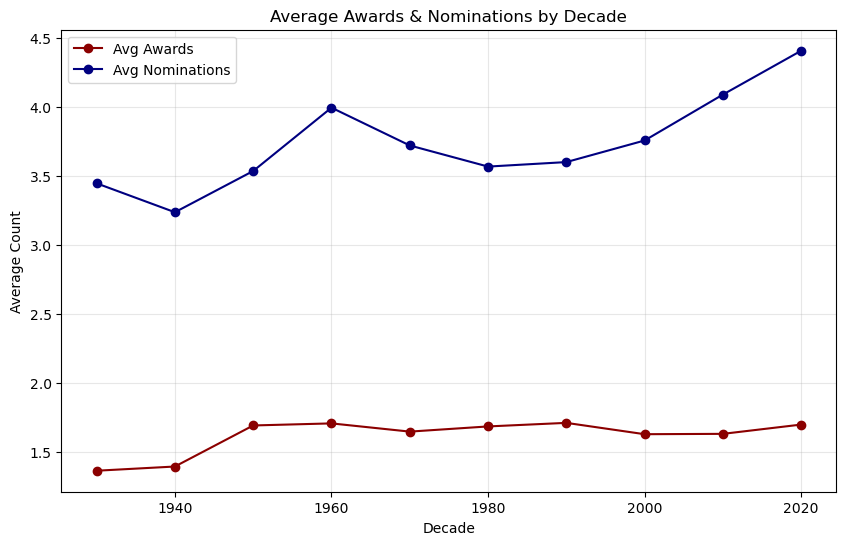

In [19]:
decade_stats= df.groupby('Decade')[['Awards', 'Nominations']].mean()

plt.figure(figsize=(10, 6))

plt.plot(decade_stats.index, decade_stats['Awards'], marker='o', label='Avg Awards', color='darkred')
plt.plot(decade_stats.index, decade_stats['Nominations'], marker='o', label='Avg Nominations', color='navy')

plt.title('Average Awards & Nominations by Decade')
plt.xlabel('Decade')
plt.ylabel('Average Count')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('trend_by_decade.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Nominations have risen steadily over the decades (3.44 → 4.41 avg), 
while awards per film stayed flat (~1.6-1.7) — likely reflecting the 
Academy expanding award categories over time rather than films getting 
"better" at winning.

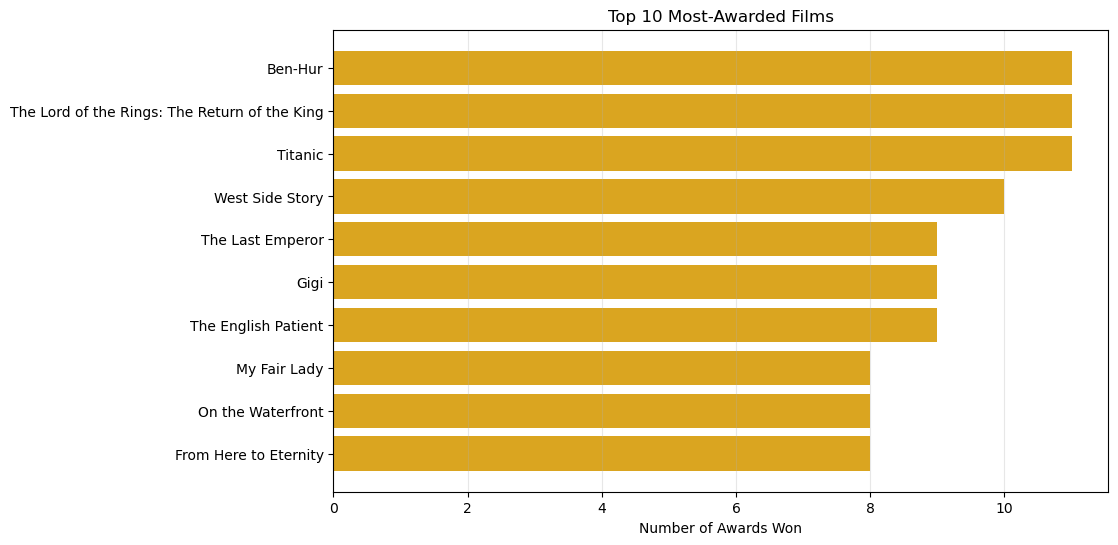

In [20]:
top10 = df.sort_values('Awards', ascending= False).head(10).sort_values('Awards')

plt.figure(figsize=(10,6))

plt.barh(top10['Film'], top10['Awards'], color= 'goldenrod')

plt.title('Top 10 Most-Awarded Films')
plt.xlabel('Number of Awards Won')
plt.ylabel('')
plt.grid(axis='x', alpha=0.3)
plt.savefig('top10_films.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Ben-Hur, Titanic, and The Lord of the Rings: The Return of the 
King share the record for most Oscars won by a single film (11 each).

In [21]:
import os
for f in os.listdir():
    if f.endswith('.png'):
        print(f)

awards_distribution.png
movies_per_decade.png
nominations_vs_awards.png
top10_films.png
trend_by_decade.png
